In [1]:
import importlib
import bvh_wav_pairstools
importlib.reload(bvh_wav_pairstools)
from bvh_wav_pairstools import Preprocessor

In [2]:
pre = Preprocessor("../wavs", "../bvhs")
s1=pre.count_bvhs()
s2=pre.count_wavs()
print(s1)
print(s2)

there are {s} bvhs
there are {s} wavs
116
116


In [3]:
pre.count_gender_from_bvh_filenames("../bvhs")

(M): 51
(F): 65
(Total):116


(Counter({'F': 65, 'M': 51}), [])

(M): 51
(F): 65
(Total):116


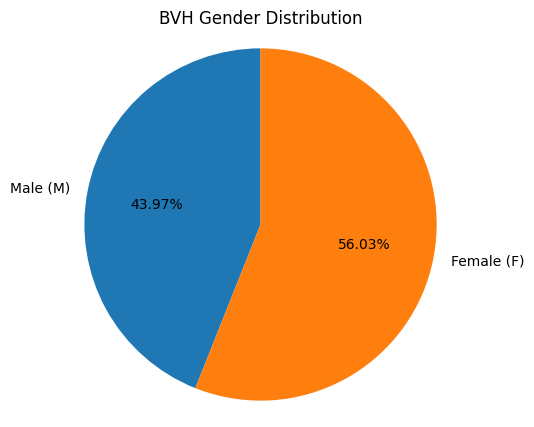

In [4]:
import matplotlib.pyplot as plt
counts, unknown = pre.count_gender_from_bvh_filenames("../bvhs")
sizes = [counts["M"], counts["F"]]
labels = ["Male (M)", "Female (F)"]
if sum(sizes) == 0:
    print("No file found")
else:
    plt.figure(figsize=(5, 5))
    plt.pie(
        sizes,
        labels=labels,
        autopct="%1.2f%%",
        startangle=90
    )
    plt.title("BVH Gender Distribution")
    plt.axis("equal")
    plt.show()

In [5]:
pre.find_quadruples("st_quads.json", "unmatched.json")

{'saved_quads': 57, 'unmatched_groups': 1}

In [6]:
import bvhtools 
importlib.reload(bvhtools)
from bvhtools import bvhtools


In [7]:
bvht = bvhtools("../bvhs")
bvhs = pre.list_bvhs()

In [8]:
meta= bvht.get_meta(bvhs[0])

In [9]:
for k in meta:
    print (meta[k])

Session_01_Take_017_Act02_M.bvh
51
['Hips', 'Spine', 'Spine1', 'Neck', 'Head', 'LeftShoulder', 'LeftArm', 'LeftForeArm', 'LeftHand', 'LeftHandThumb1', 'LeftHandThumb2', 'LeftHandThumb3', 'LeftHandIndex1', 'LeftHandIndex2', 'LeftHandIndex3', 'LeftHandMiddle1', 'LeftHandMiddle2', 'LeftHandMiddle3', 'LeftHandRing1', 'LeftHandRing2', 'LeftHandRing3', 'LeftHandPinky1', 'LeftHandPinky2', 'LeftHandPinky3', 'RightShoulder', 'RightArm', 'RightForeArm', 'RightHand', 'RightHandThumb1', 'RightHandThumb2', 'RightHandThumb3', 'RightHandIndex1', 'RightHandIndex2', 'RightHandIndex3', 'RightHandMiddle1', 'RightHandMiddle2', 'RightHandMiddle3', 'RightHandRing1', 'RightHandRing2', 'RightHandRing3', 'RightHandPinky1', 'RightHandPinky2', 'RightHandPinky3', 'LeftUpLeg', 'LeftLeg', 'LeftFoot', 'LeftToeBase', 'RightUpLeg', 'RightLeg', 'RightFoot', 'RightToeBase']
22269
0.016667
60


In [10]:
dm1 = bvht.get_motion(bvhs[0])
print(dm1["motion"].shape) # 156 = 51*3 + 3

(22269, 156)


In [11]:
dm2 = bvht.get_xyz_and_lower_motion(bvhs[0])

In [12]:
dm6d = bvht.euler_motion_to_rot6d(bvhs[0],dm1["motion"])


In [13]:
print(dm6d.keys())
print(dm6d['motion'].shape)


dict_keys(['motion', 'columns', 'num_frames', 'num_channels'])
(22269, 309)


In [14]:
print(len(dm6d['columns']))
print(dm6d['num_frames'])

309
22269


In [15]:
dmrot = bvht.rot6d_motion_to_euler(bvhs[0],dm6d['motion'])
print(dmrot.keys())


dict_keys(['motion', 'columns', 'num_frames', 'num_channels'])


In [16]:
dmrot['motion'].shape


(22269, 156)

In [17]:
bvht.motion_to_bvh(bvhs[0],dmrot['motion'],"./restorebvhs/retore01.bvh")

{'motion': array([[ 5.55618896e+01,  9.47435074e+01, -1.52463196e+02, ...,
         -1.20565399e-15, -1.17121196e+00,  9.99999997e-07],
        [ 5.58789749e+01,  9.44036560e+01, -1.54117920e+02, ...,
          4.27120302e-15, -2.72941804e+00,  1.99999999e-06],
        [ 5.58219719e+01,  9.41820297e+01, -1.53999634e+02, ...,
         -0.00000000e+00, -3.07253599e+00,  0.00000000e+00],
        ...,
        [-1.00086258e+02,  8.93707352e+01, -2.90386932e+02, ...,
          1.04428945e-15, -2.44639492e+00,  6.00000021e-06],
        [-1.00262054e+02,  8.92204971e+01, -2.92091309e+02, ...,
         -9.99999997e-07, -3.34412098e+00, -3.99999999e-06],
        [-1.00500961e+02,  8.91237106e+01, -2.93857513e+02, ...,
         -5.47613280e-15, -4.45329094e+00,  3.99999999e-06]],
       shape=(22269, 156), dtype=float32),
 'num_frames': 22269,
 'num_channels': 156,
 'out_bvh': 'restorebvhs/retore01.bvh'}

In [18]:
dm2 = bvht.get_motion(bvhs[0],as_dict=True)



In [19]:
print(dm2["motion_by_joint"]["Hips"]["channels"])
print(dm2["motion_by_joint"]["Hips"]["values"])
print(dm2["motion_by_joint"]["Hips"]["values"].shape)

['Xposition', 'Yposition', 'Zposition', 'Zrotation', 'Xrotation', 'Yrotation']
[[ 5.55618896e+01  9.47435074e+01 -1.52463196e+02 -1.69015005e-01
  -2.21408391e+00  1.74681183e+02]
 [ 5.58789749e+01  9.44036560e+01 -1.54117920e+02 -5.97169995e-02
  -1.66637003e+00  1.73754562e+02]
 [ 5.58219719e+01  9.41820297e+01 -1.53999634e+02 -1.18442997e-01
  -1.58610296e+00  1.73027542e+02]
 ...
 [-1.00086258e+02  8.93707352e+01 -2.90386932e+02  3.61851311e+00
   5.11935902e+00  1.70889709e+02]
 [-1.00262054e+02  8.92204971e+01 -2.92091309e+02  3.36783099e+00
   5.13279104e+00  1.70332245e+02]
 [-1.00500961e+02  8.91237106e+01 -2.93857513e+02  3.05933094e+00
   5.14675903e+00  1.69721283e+02]]
(22269, 6)


In [20]:
pos = dm2["motion_by_joint"]["Hips"]["values"][:,[0,2]]
print(pos.shape)

(22269, 2)


In [21]:
dm3 = bvht.export_no_finger_bvh(bvhs[0])

In [22]:
bvht2 = bvhtools("./bvhsnofingers")
bvhs2 = pre.list_allfiles("./bvhsnofingers")

In [23]:
c3 = bvht2.get_motion(bvhs2[0],as_dict=True)

In [24]:
print(c3.keys())
len(c3['motion_by_joint'])
print(c3['motion_by_joint'].keys())

dict_keys(['file', 'motion_by_joint', 'num_frames'])
dict_keys(['Hips', 'Spine', 'Spine1', 'Neck', 'Head', 'LeftShoulder', 'LeftArm', 'LeftForeArm', 'LeftHand', 'RightShoulder', 'RightArm', 'RightForeArm', 'RightHand', 'LeftUpLeg', 'LeftLeg', 'LeftFoot', 'LeftToeBase', 'RightUpLeg', 'RightLeg', 'RightFoot', 'RightToeBase'])


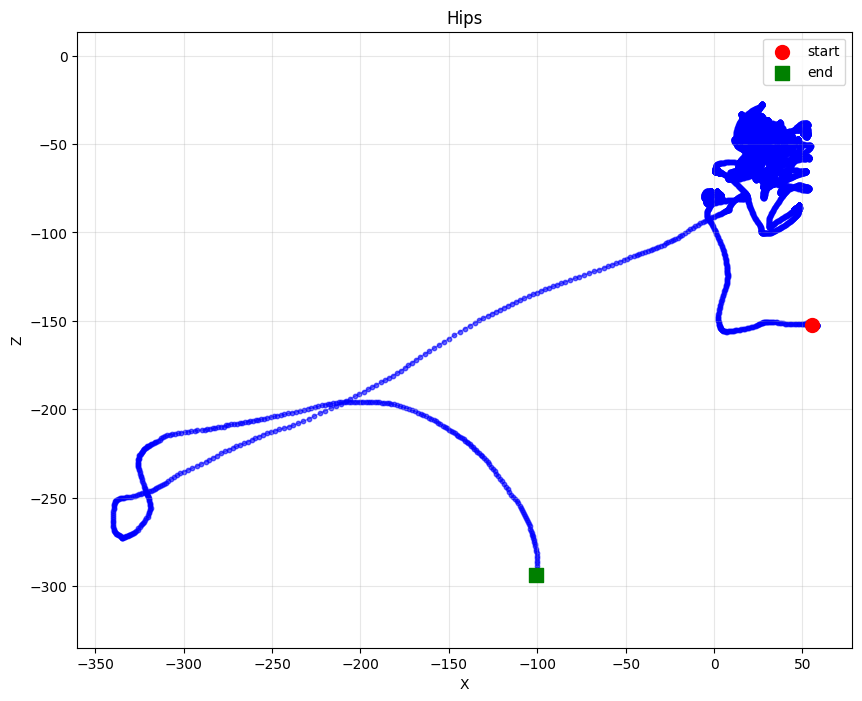

In [25]:
import matplotlib.pyplot as plt

pos = dm2["motion_by_joint"]["Hips"]["values"][:, [0, 2]]

plt.figure(figsize=(10, 8))

# 所有点固定同一种颜色
plt.scatter(pos[:, 0], pos[:, 1], color='blue', s=10, alpha=0.6)

# 轨迹线固定同一种颜色
plt.plot(pos[:, 0], pos[:, 1], color='blue', alpha=0.5, linewidth=0.8)

# 起点和终点
plt.scatter(pos[0, 0], pos[0, 1], color='red', s=100, marker='o', label='start', zorder=5)
plt.scatter(pos[-1, 0], pos[-1, 1], color='green', s=100, marker='s', label='end', zorder=5)

plt.xlabel('X')
plt.ylabel('Z')
plt.title('Hips')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
import json

In [27]:
with open("st_quads.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [28]:
print(len(data))

57


In [29]:
print(data[0]["bvh0"])
print(data[0]["bvh1"])

Session_01_Take_012_Act02_M.bvh
Session_01_Take_012_Act04_M.bvh


In [30]:
c1 = bvht.get_motion(data[0]["bvh0"],as_dict=True)
c2 = bvht.get_motion(data[0]["bvh1"],as_dict=True)
p1 = c1["motion_by_joint"]["Hips"]["values"][:,[0,2]]
p2 = c2["motion_by_joint"]["Hips"]["values"][:,[0,2]]

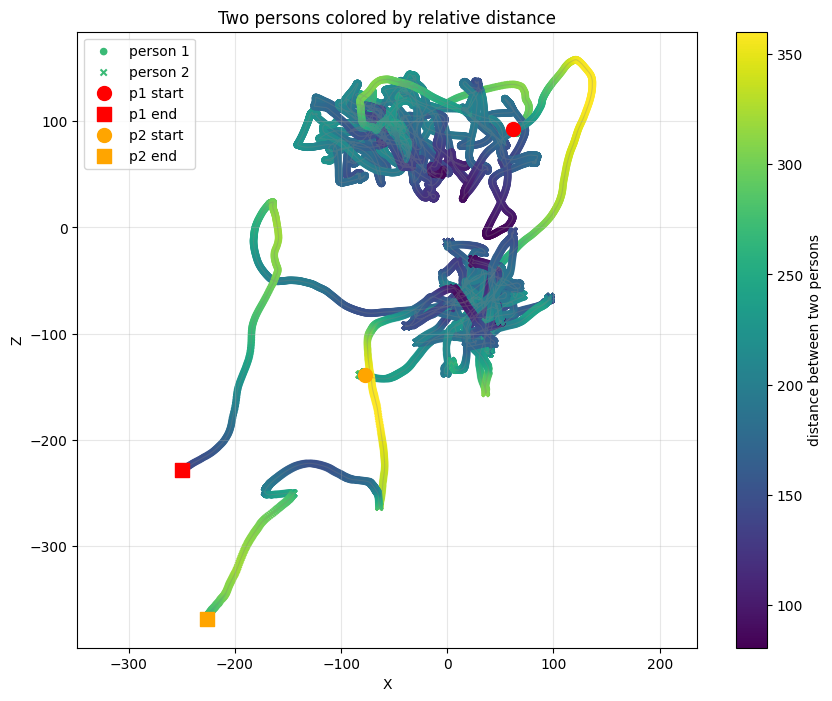

In [31]:
import numpy as np
import matplotlib.pyplot as plt

p1 = c1["motion_by_joint"]["Hips"]["values"][:, [0, 2]]  # person 1: x,z
p2 = c2["motion_by_joint"]["Hips"]["values"][:, [0, 2]]  # person 2: x,z

# 如果两个人帧数不一样，先截到同样长度
T = min(len(p1), len(p2))
p1 = p1[:T]
p2 = p2[:T]

# 每一帧两人之间的平面距离
dist = np.linalg.norm(p1 - p2, axis=1)   # shape (T,)

plt.figure(figsize=(10, 8))

# 用同一个 dist 给两个人上色
sc1 = plt.scatter(p1[:, 0], p1[:, 1], c=dist, cmap='viridis', s=20, label='person 1')
plt.plot(p1[:, 0], p1[:, 1], color='gray', alpha=0.3, linewidth=0.8)

plt.scatter(p2[:, 0], p2[:, 1], c=dist, cmap='viridis', s=20, marker='x', label='person 2')
plt.plot(p2[:, 0], p2[:, 1], color='gray', alpha=0.3, linewidth=0.8)

# 起点终点
plt.scatter(p1[0, 0], p1[0, 1], color='red', s=100, marker='o', zorder=5, label='p1 start')
plt.scatter(p1[-1, 0], p1[-1, 1], color='red', s=100, marker='s', zorder=5, label='p1 end')

plt.scatter(p2[0, 0], p2[0, 1], color='orange', s=100, marker='o', zorder=5, label='p2 start')
plt.scatter(p2[-1, 0], p2[-1, 1], color='orange', s=100, marker='s', zorder=5, label='p2 end')

plt.xlabel("X")
plt.ylabel("Z")
plt.title("Two persons colored by relative distance")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.colorbar(sc1, label="distance between two persons")
plt.show()

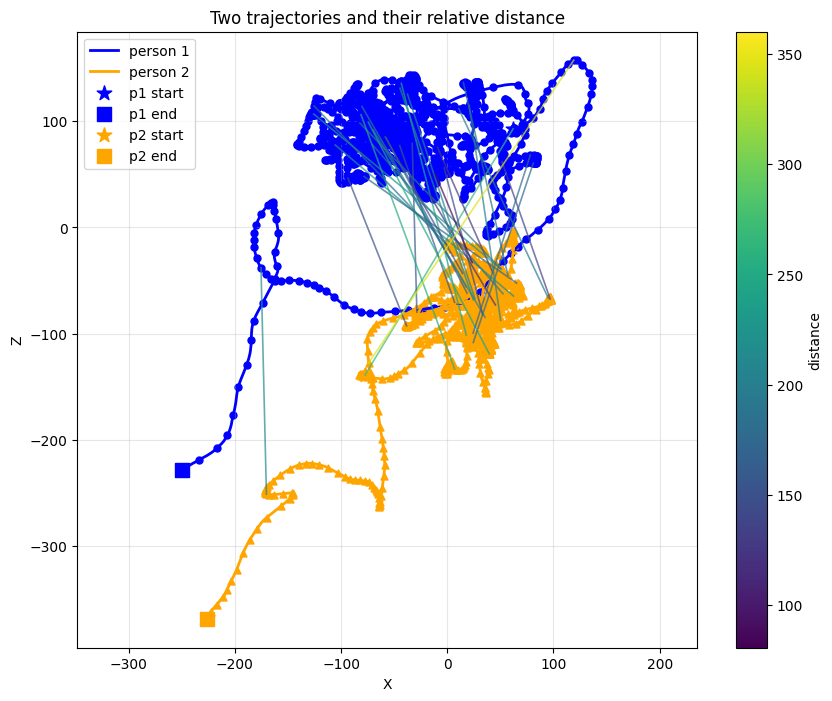

In [32]:
import numpy as np
import matplotlib.pyplot as plt

p1 = c1["motion_by_joint"]["Hips"]["values"][:, [0, 2]]
p2 = c2["motion_by_joint"]["Hips"]["values"][:, [0, 2]]

T = min(len(p1), len(p2))
p1 = p1[:T]
p2 = p2[:T]

dist = np.linalg.norm(p1 - p2, axis=1)

fig, ax = plt.subplots(figsize=(10, 8))

# 两个人的轨迹
ax.plot(p1[:, 0], p1[:, 1], color='blue', linewidth=2, label='person 1')
ax.plot(p2[:, 0], p2[:, 1], color='orange', linewidth=2, label='person 2')

# 稀疏采样点
step = 10
ax.scatter(p1[::step, 0], p1[::step, 1], color='blue', s=25, marker='o')
ax.scatter(p2[::step, 0], p2[::step, 1], color='orange', s=25, marker='^')

# 起点终点
ax.scatter(p1[0, 0], p1[0, 1], color='blue', s=120, marker='*', label='p1 start')
ax.scatter(p1[-1, 0], p1[-1, 1], color='blue', s=100, marker='s', label='p1 end')

ax.scatter(p2[0, 0], p2[0, 1], color='orange', s=120, marker='*', label='p2 start')
ax.scatter(p2[-1, 0], p2[-1, 1], color='orange', s=100, marker='s', label='p2 end')

# 连线颜色表示距离
norm = plt.Normalize(dist.min(), dist.max())
cmap = plt.cm.viridis
step =500
for i in range(0, T, step):
    ax.plot(
        [p1[i, 0], p2[i, 0]],
        [p1[i, 1], p2[i, 1]],
        color=cmap(norm(dist[i])),
        alpha=0.7,
        linewidth=1.2
    )

# 显式绑定到 ax
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='distance')

ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_title("Two trajectories and their relative distance")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

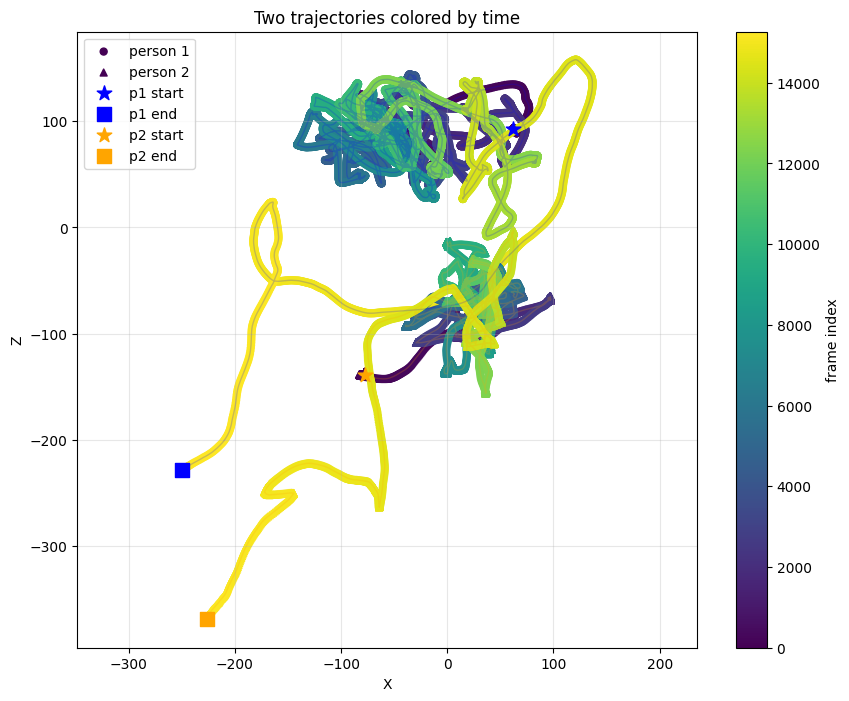

In [33]:
import numpy as np
import matplotlib.pyplot as plt

p1 = c1["motion_by_joint"]["Hips"]["values"][:, [0, 2]]
p2 = c2["motion_by_joint"]["Hips"]["values"][:, [0, 2]]

T = min(len(p1), len(p2))
p1 = p1[:T]
p2 = p2[:T]

t = np.arange(T)

fig, ax = plt.subplots(figsize=(10, 8))

# 两个人共享同一个时间颜色
sc = ax.scatter(
    p1[:, 0], p1[:, 1],
    c=t, cmap="viridis",
    s=25, marker="o",
    label="person 1"
)

ax.scatter(
    p2[:, 0], p2[:, 1],
    c=t, cmap="viridis",
    s=25, marker="^",
    label="person 2"
)

# 淡淡的轨迹线
ax.plot(p1[:, 0], p1[:, 1], color="blue", alpha=0.2, linewidth=1.0)
ax.plot(p2[:, 0], p2[:, 1], color="orange", alpha=0.2, linewidth=1.0)

# 起点终点
ax.scatter(p1[0, 0], p1[0, 1], color="blue", s=120, marker="*", zorder=5, label="p1 start")
ax.scatter(p1[-1, 0], p1[-1, 1], color="blue", s=100, marker="s", zorder=5, label="p1 end")

ax.scatter(p2[0, 0], p2[0, 1], color="orange", s=120, marker="*", zorder=5, label="p2 start")
ax.scatter(p2[-1, 0], p2[-1, 1], color="orange", s=100, marker="s", zorder=5, label="p2 end")

fig.colorbar(sc, ax=ax, label="frame index")

ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_title("Two trajectories colored by time")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [34]:
from analysis_tools import compute_body_entropy_per_file

file_results, actor_results, meta = compute_body_entropy_per_file(
    folder="../bvhs",
    recursive=False,
    top_k=20,
    num_bins=100,
    normalized=False
)

print(file_results[:5])
print(actor_results)

[{'file': 'Session_01_Take_012_Act02_M.bvh', 'actor': 'Act02', 'entropy': 0.779978}, {'file': 'Session_01_Take_012_Act04_M.bvh', 'actor': 'Act04', 'entropy': 0.352825}, {'file': 'Session_01_Take_013_Act02_M.bvh', 'actor': 'Act02', 'entropy': 0.307183}, {'file': 'Session_01_Take_013_Act04_M.bvh', 'actor': 'Act04', 'entropy': 0.301911}, {'file': 'Session_01_Take_014_Act02_M.bvh', 'actor': 'Act02', 'entropy': 0.22931}]
[{'actor': 'Act01', 'num_files': 8, 'mean_entropy': 0.164626, 'std_entropy': 0.050051, 'min_entropy': 0.104277, 'max_entropy': 0.247169}, {'actor': 'Act02', 'num_files': 10, 'mean_entropy': 0.336268, 'std_entropy': 0.162345, 'min_entropy': 0.171805, 'max_entropy': 0.779978}, {'actor': 'Act03', 'num_files': 23, 'mean_entropy': 0.37536, 'std_entropy': 0.139229, 'min_entropy': 0.178834, 'max_entropy': 0.717009}, {'actor': 'Act04', 'num_files': 17, 'mean_entropy': 0.316916, 'std_entropy': 0.104011, 'min_entropy': 0.10752, 'max_entropy': 0.558428}, {'actor': 'Act05', 'num_files'

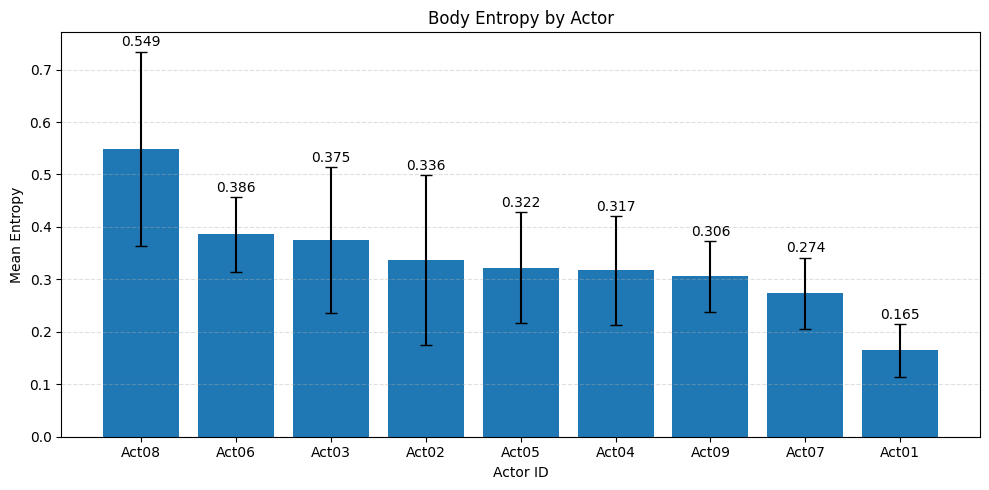

In [35]:
actor_results = sorted(actor_results, key=lambda x: x["mean_entropy"], reverse=True)

actors = [x["actor"] for x in actor_results]
means = [x["mean_entropy"] for x in actor_results]
stds = [x["std_entropy"] for x in actor_results]

x = np.arange(len(actors))

plt.figure(figsize=(10, 5))
bars = plt.bar(x, means, yerr=stds, capsize=4)

plt.xticks(x, actors)
plt.ylabel("Mean Entropy")
plt.xlabel("Actor ID")
plt.title("Body Entropy by Actor")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(means):
    plt.text(i, v + stds[i] + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()